<a href="https://colab.research.google.com/github/Sanjana-Munikrishnappa/ML_Saftey_Retrained/blob/ML-Saftey-Retrained/ML_Excercise_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Mounting Google Drive
Mounts your Google Drive to the Colab environment, allowing access to files stored in your Drive.

In [ ]:
from google.colab.drive import mount
mount('/content/drive')

Mounted at /content/drive


## Listing Dataset Contents
Sets the path to the CARLA dataset in Google Drive and then lists its contents to verify the files.

In [ ]:
import os

dataset_path = "/content/drive/MyDrive/carla_dataset"

files = os.listdir(dataset_path)
print(files)

['test.zip', 'train.zip', 'validation.zip', 'train', 'test', 'validation', 'test-fog.zip', 'test-night.zip', 'test-town-01.zip', 'traffic_light_model.pth', 'pedestrian_model.pth', 'vehicle_model.pth']


## Extracting Zipped Datasets
Extracts the 'train.zip', 'validation.zip', and 'test.zip' files into their respective directories, making the image and label data accessible.

In [ ]:
import zipfile
from pathlib import Path

base_path = Path("/content/drive/MyDrive/carla_dataset")

archives = {
    "train.zip": "train",
    "validation.zip": "validation",
    "test.zip": "test"
}

for archive, destination in archives.items():
    with zipfile.ZipFile(base_path / archive, "r") as z:
        z.extractall(destination)

print("Dataset extracted successfully!")

Dataset extracted successfully!


## Importing Necessary Libraries
Imports all the required Python libraries for data manipulation, image processing, deep learning with PyTorch, and transformations.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset

import torchvision.transforms as T

transforms = T

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Loading Label DataFrames
Defines paths to the CSV files containing labels for the train, validation, and test datasets, then loads them into pandas DataFrames.

In [ ]:
from pathlib import Path

root = Path.cwd()

train_csv = root / "train" / "train" / "labels.csv"
val_csv = root / "validation" / "validation" / "labels.csv"
test_csv = root / "test" / "test" / "labels.csv"

labels_df_train = pd.read_csv(train_csv)
labels_df_val = pd.read_csv(val_csv)
labels_df_test = pd.read_csv(test_csv)

print(f"Training Dataset Shape: {labels_df_train.shape}")

labels_df_train.head()

Training Dataset Shape: (7200, 7)


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,True,0,0,85
1,10,False,True,True,14,301,1138
2,20,True,True,True,99,196,517
3,30,True,True,True,99,181,530
4,40,True,True,True,101,169,538


## Defining Image Transformations
Sets the desired image size and creates a transformation pipeline using `torchvision.transforms` to resize images and convert them to PyTorch tensors.

In [ ]:
image_size = (224, 224)

transform = transforms.Compose(
    [
        transforms.Resize(image_size),
        transforms.ToTensor()
    ]
)

message = "Transform created!"
print(message)

Transform created!


## Custom Dataset Class: DrivingDataset
Defines a custom PyTorch `Dataset` class to handle loading images and their corresponding labels for training, validation, and testing. It preprocesses images using the defined transform and returns image-label pairs.

In [ ]:
class DrivingDataset(Dataset):
    def __init__(self, image_folder, labels_df, target_column, transform=None):
        self.directory = image_folder
        self.data = labels_df.reset_index(drop=True)
        self.target = target_column
        self.transform = transform

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, index):
        record = self.data.iloc[index]

        img_name = "{:06d}.jpg".format(record["frame"])
        img_path = os.path.join(self.directory, img_name)

        img = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        target = torch.tensor(int(record[self.target]))

        return img, target

## Initializing Traffic Light Training Dataset
Creates an instance of the `DrivingDataset` for the traffic light detection task using the training data and displays the total number of samples.

In [ ]:
dataset_args = {
    "image_folder": "train/train/rgb-front",
    "labels_df": labels_df_train,
    "target_column": "has_traffic_light",
    "transform": transform
}

traffic_light_dataset = DrivingDataset(**dataset_args)

sample_count = len(traffic_light_dataset)
print("Training samples:", sample_count)

Training samples: 7200


## Inspecting a Sample from the Dataset
Retrieves and displays the shape of an image tensor and its corresponding label from the dataset to verify the data loading process.

In [ ]:
sample = traffic_light_dataset.__getitem__(0)

img_tensor = sample[0]
target_label = sample[1]

print("Image shape:", img_tensor.size())
print("Label:", target_label)

Image shape: torch.Size([3, 224, 224])
Label: tensor(0)


## Initializing Traffic Light Test Dataset
Creates an instance of the `DrivingDataset` for the traffic light detection task using the test data and displays the total number of samples.

In [ ]:
test_config = {
    "image_folder": "test/test/rgb-front",
    "labels_df": labels_df_test,
    "target_column": "has_traffic_light",
    "transform": transform
}

test_dataset = DrivingDataset(**test_config)

total_samples = len(test_dataset)
print("Test samples:", total_samples)

Test samples: 3600


## Setting up Traffic Light Test DataLoader
Configures and initializes a PyTorch `DataLoader` for the traffic light test dataset, which will be used to iterate over batches of test data.

In [ ]:
loader_params = {
    "dataset": test_dataset,
    "batch_size": 32,
    "shuffle": False
}

test_loader = DataLoader(**loader_params)

batch_count = len(test_loader)
print("Number of batches:", batch_count)

Number of batches: 113


## Detecting Available Device (CPU/GPU)
Checks if a CUDA-enabled GPU is available and sets the `device` variable accordingly. If no GPU is found, it defaults to using the CPU.

In [ ]:
available_gpu = torch.cuda.is_available()

device = torch.device("cuda" if available_gpu else "cpu")

print(str(device))

cpu


## Neural Network Architecture: TrafficLightClassifier
Defines the convolutional neural network (`CNN`) architecture, `TrafficLightClassifier`, designed to classify whether an image contains a traffic light. It consists of convolutional layers, ReLU activations, max-pooling, a flattening layer, and fully connected layers.

In [ ]:
class TrafficLightClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        layers = [
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Flatten(),

            nn.Linear(in_features=64 * 28 * 28, out_features=128),
            nn.ReLU(inplace=True),

            nn.Linear(in_features=128, out_features=1)
        ]

        self.model = nn.Sequential(*layers)

    def forward(self, inputs):
        outputs = self.model(inputs)
        return outputs

## Initializing the Traffic Light Model
Creates an instance of the `TrafficLightClassifier` and moves it to the detected device (GPU or CPU), then prints a representation of the model's structure.

In [ ]:
classifier = TrafficLightClassifier()

model = classifier.to(device)

print(model.__repr__())

TrafficLightClassifier(
  (model): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=50176, out_features=128, bias=True)
    (11): ReLU(inplace=True)
    (12): Linear(in_features=128, out_features=1, bias=True)
  )
)


## Listing Saved Models in Google Drive
Iterates through the user's Google Drive to find and print the paths of all saved PyTorch model files (`.pth`).

In [ ]:
from pathlib import Path

drive_path = Path("/content/drive/MyDrive")

for model_file in drive_path.rglob("*.pth"):
    print(model_file)

/content/drive/MyDrive/carla_dataset/traffic_light_model.pth
/content/drive/MyDrive/carla_dataset/pedestrian_model.pth
/content/drive/MyDrive/carla_dataset/vehicle_model.pth


## Re-initializing Traffic Light Model
Re-initializes the `TrafficLightClassifier` model and moves it to the appropriate device (GPU or CPU). This is a duplicate of a previous initialization but potentially for different stages or purposes.

In [ ]:
network = TrafficLightClassifier()

model = network.to(device)

## Configuring Loss Function and Optimizer
Defines the binary cross-entropy loss with logits (`nn.BCEWithLogitsLoss`) and the Adam optimizer, which are crucial components for training the neural network.

In [ ]:
loss_fn = nn.BCEWithLogitsLoss()

learning_rate = 1e-3
optimizer = optim.Adam(params=model.parameters(), lr=learning_rate)

criterion = loss_fn

print("Loss and optimizer created")

Loss and optimizer created


## Setting up Traffic Light Training DataLoader
Configures and initializes a PyTorch `DataLoader` for the traffic light training dataset, enabling batch processing and shuffling of data during training.

In [ ]:
from torch.utils.data import DataLoader

loader_config = {
    "dataset": traffic_light_dataset,
    "batch_size": 32,
    "shuffle": True
}

train_loader = DataLoader(**loader_config)

total_batches = len(train_loader)
print("Number of training batches:", total_batches)

Number of training batches: 225


## Setting up Traffic Light Validation Dataset and DataLoader
Creates a `DrivingDataset` and a `DataLoader` for the traffic light validation data, used to monitor model performance during training.

In [ ]:
validation_config = {
    "image_folder": "validation/validation/rgb-front",
    "labels_df": labels_df_val,
    "target_column": "has_traffic_light",
    "transform": transform
}

val_dataset = DrivingDataset(**validation_config)

loader_options = {
    "dataset": val_dataset,
    "batch_size": 32,
    "shuffle": False
}

val_loader = DataLoader(**loader_options)

validation_count = len(val_dataset)
print("Validation samples:", validation_count)

Validation samples: 3600


## Training the Traffic Light Classifier Model
Contains the main training loop for the traffic light classification model. It iterates over epochs, processes batches of data, calculates loss, performs backpropagation, and updates model weights.

In [ ]:
epochs = 3

losses = []

for current_epoch in range(epochs):

    model.train()

    epoch_loss = 0

    for batch in train_loader:

        inputs, targets = batch

        inputs = inputs.to(device)
        targets = targets.unsqueeze(1).float().to(device)

        optimizer.zero_grad(set_to_none=True)

        predictions = model(inputs)

        batch_loss = criterion(predictions, targets)

        batch_loss.backward()

        optimizer.step()

        epoch_loss += batch_loss.item()

    mean_loss = epoch_loss / len(train_loader)

    losses.append(mean_loss)

    print("Epoch {}/{}, Loss: {:.4f}".format(current_epoch + 1, epochs, mean_loss))

Epoch 1/3, Loss: 0.4397
Epoch 2/3, Loss: 0.2250
Epoch 3/3, Loss: 0.1422


## Visualizing Traffic Light Training Loss
Generates a plot of the training loss over epochs, allowing for visual inspection of the model's learning progress.

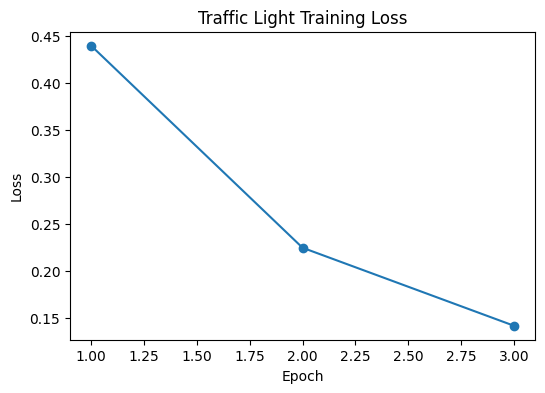

In [ ]:
epochs = range(1, len(losses) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Traffic Light Training Loss")
plt.grid(False)
plt.show()

## Importing Scikit-learn Metrics
Imports various evaluation metrics from `sklearn.metrics`, including `ConfusionMatrixDisplay`, `confusion_matrix`, `f1_score`, `precision_score`, and `recall_score`, which are used to assess model performance.

In [ ]:
import numpy as np

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

## Evaluating Traffic Light Model Performance
Evaluates the trained traffic light model on the test dataset. It calculates precision, recall, and F1-score to quantify the model's accuracy in detecting traffic lights.

In [ ]:
model.eval()

true_labels = []
predicted_labels = []

with torch.inference_mode():

    for batch in test_loader:

        inputs, targets = batch

        inputs = inputs.to(device)

        scores = model(inputs)

        predictions = torch.sigmoid(scores).ge(0.5)

        predicted_labels += predictions.view(-1).cpu().tolist()
        true_labels += targets.tolist()

precision = precision_score(true_labels, predicted_labels)
recall = recall_score(true_labels, predicted_labels)
f1 = f1_score(true_labels, predicted_labels)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

Precision: 0.9150255288110868
Recall: 0.9709752321981424
F1-score: 0.9421704844160721


## Visualizing Traffic Light Confusion Matrix
Generates and displays a confusion matrix for the traffic light classifier, providing a detailed breakdown of correct and incorrect predictions.

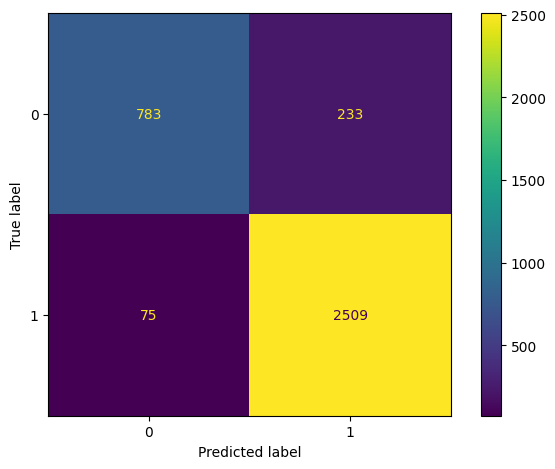

In [ ]:
matrix = confusion_matrix(true_labels, predicted_labels)

plot = ConfusionMatrixDisplay(matrix)

plot.plot()

plt.tight_layout()
plt.show()

## Initializing Pedestrian Detection Datasets
Creates separate `DrivingDataset` instances for training, validation, and testing of the pedestrian detection task, specifying "has_pedestrian" as the target column.

In [ ]:
dataset_info = {
    "train": ("train/train/rgb-front", labels_df_train),
    "validation": ("validation/validation/rgb-front", labels_df_val),
    "test": ("test/test/rgb-front", labels_df_test)
}

pedestrian_train_dataset = DrivingDataset(
    image_folder=dataset_info["train"][0],
    labels_df=dataset_info["train"][1],
    target_column="has_pedestrian",
    transform=transform
)

pedestrian_val_dataset = DrivingDataset(
    image_folder=dataset_info["validation"][0],
    labels_df=dataset_info["validation"][1],
    target_column="has_pedestrian",
    transform=transform
)

pedestrian_test_dataset = DrivingDataset(
    image_folder=dataset_info["test"][0],
    labels_df=dataset_info["test"][1],
    target_column="has_pedestrian",
    transform=transform
)

print(len(pedestrian_train_dataset))
print(len(pedestrian_val_dataset))
print(len(pedestrian_test_dataset))

7200
3600
3600


## Setting up Pedestrian Detection DataLoaders
Configures and initializes PyTorch `DataLoader` objects for the pedestrian detection datasets, enabling efficient batch processing during training and evaluation.

In [ ]:
loader_settings = {
    "batch_size": 32
}

pedestrian_train_loader = DataLoader(
    dataset=pedestrian_train_dataset,
    shuffle=True,
    **loader_settings
)

pedestrian_val_loader = DataLoader(
    dataset=pedestrian_val_dataset,
    shuffle=False,
    **loader_settings
)

pedestrian_test_loader = DataLoader(
    dataset=pedestrian_test_dataset,
    shuffle=False,
    **loader_settings
)

train_batches = len(pedestrian_train_loader)
print(train_batches)

225


## Initializing the Pedestrian Detection Model
Creates a new instance of the `TrafficLightClassifier` (repurposing the architecture for pedestrian detection) and sets up the loss function and optimizer for its training.

In [ ]:
pedestrian_network = TrafficLightClassifier()

pedestrian_model = pedestrian_network.to(device)

loss_function = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    params=pedestrian_model.parameters(),
    lr=1e-3
)

criterion = loss_function

print("Pedestrian model created")

Pedestrian model created


## Training the Pedestrian Detection Model
Contains the training loop for the pedestrian detection model, similar to the traffic light model. It trains the model over a specified number of epochs, calculating and printing the loss.

In [ ]:
epochs = 3

losses = []

for current_epoch in range(epochs):

    pedestrian_model.train()

    total_loss = 0.0

    for batch_images, batch_labels in pedestrian_train_loader:

        batch_images = batch_images.to(device)
        batch_labels = batch_labels.unsqueeze(1).float().to(device)

        optimizer.zero_grad(set_to_none=True)

        predictions = pedestrian_model(batch_images)

        current_loss = criterion(predictions, batch_labels)

        current_loss.backward()

        optimizer.step()

        total_loss += current_loss.item()

    epoch_loss = total_loss / len(pedestrian_train_loader)

    losses.append(epoch_loss)

    print("Epoch {}/{}, Loss: {:.4f}".format(current_epoch + 1, epochs, epoch_loss))

Epoch 1/3, Loss: 0.5477
Epoch 2/3, Loss: 0.5069
Epoch 3/3, Loss: 0.4740


## Visualizing Pedestrian Training Loss
Plots the training loss for the pedestrian detection model over epochs, showing its learning curve.

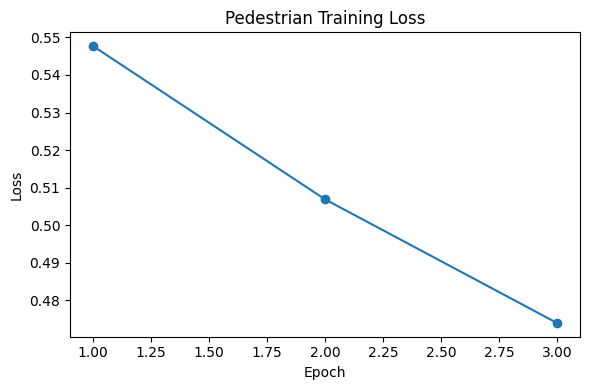

In [ ]:
epoch_numbers = list(range(1, len(losses) + 1))

plt.figure(figsize=(6, 4))
plt.plot(epoch_numbers, losses, marker="o")
plt.title("Pedestrian Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(False)
plt.tight_layout()
plt.show()

## Evaluating Pedestrian Detection Model Performance
Evaluates the trained pedestrian detection model on the test set, calculating precision, recall, and F1-score to measure its effectiveness.

In [ ]:
pedestrian_model.eval()

actual_labels = []
predicted_labels = []

with torch.inference_mode():

    for batch_images, batch_labels in pedestrian_test_loader:

        batch_images = batch_images.to(device)

        logits = pedestrian_model(batch_images)

        predicted = torch.sigmoid(logits).ge(0.5)

        predicted_labels.extend(predicted.view(-1).cpu().tolist())
        actual_labels.extend(batch_labels.tolist())

precision = precision_score(actual_labels, predicted_labels)
recall = recall_score(actual_labels, predicted_labels)
f1 = f1_score(actual_labels, predicted_labels)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

Precision: 0.22077922077922077
Recall: 0.09631728045325778
F1-score: 0.1341222879684418


## Visualizing Pedestrian Detection Confusion Matrix
Generates and displays a confusion matrix for the pedestrian detection model, showing its true positives, true negatives, false positives, and false negatives.

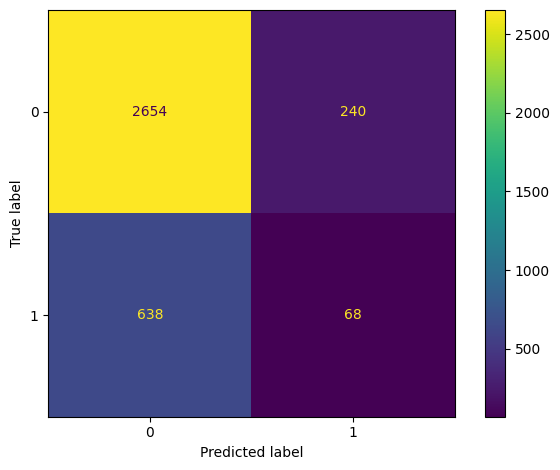

In [ ]:
matrix = confusion_matrix(actual_labels, predicted_labels)

display = ConfusionMatrixDisplay(matrix)

display.plot()

plt.tight_layout()
plt.show()

## Initializing Vehicle Detection Datasets and DataLoaders
Creates `DrivingDataset` instances and corresponding `DataLoader`s for training, validation, and testing of the vehicle detection task.

In [ ]:
vehicle_data = {
    "train": ("train/train/rgb-front", labels_df_train),
    "validation": ("validation/validation/rgb-front", labels_df_val),
    "test": ("test/test/rgb-front", labels_df_test)
}

vehicle_train_dataset = DrivingDataset(
    image_folder=vehicle_data["train"][0],
    labels_df=vehicle_data["train"][1],
    target_column="has_vehicle",
    transform=transform
)

vehicle_val_dataset = DrivingDataset(
    image_folder=vehicle_data["validation"][0],
    labels_df=vehicle_data["validation"][1],
    target_column="has_vehicle",
    transform=transform
)

vehicle_test_dataset = DrivingDataset(
    image_folder=vehicle_data["test"][0],
    labels_df=vehicle_data["test"][1],
    target_column="has_vehicle",
    transform=transform
)

loader_args = {"batch_size": 32}

vehicle_train_loader = DataLoader(
    dataset=vehicle_train_dataset,
    shuffle=True,
    **loader_args
)

vehicle_val_loader = DataLoader(
    dataset=vehicle_val_dataset,
    shuffle=False,
    **loader_args
)

vehicle_test_loader = DataLoader(
    dataset=vehicle_test_dataset,
    shuffle=False,
    **loader_args
)

print(len(vehicle_train_dataset))
print(len(vehicle_val_dataset))
print(len(vehicle_test_dataset))

7200
3600
3600


## Initializing the Vehicle Detection Model
Sets up a new `TrafficLightClassifier` model (adapted for vehicle detection) along with its loss function and optimizer.

In [ ]:
vehicle_network = TrafficLightClassifier()

vehicle_model = vehicle_network.to(device)

loss_function = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    params=vehicle_model.parameters(),
    lr=1e-3
)

criterion = loss_function

print("Vehicle model created")

Vehicle model created


## Training the Vehicle Detection Model
Executes the training loop for the vehicle detection model, iterating through epochs to optimize its performance.

In [ ]:
epochs = 3

losses = []

for current_epoch in range(epochs):

    vehicle_model.train()

    total_loss = 0.0

    for batch_images, batch_labels in vehicle_train_loader:

        batch_images = batch_images.to(device)
        batch_labels = batch_labels.unsqueeze(1).float().to(device)

        optimizer.zero_grad(set_to_none=True)

        predictions = vehicle_model(batch_images)

        batch_loss = criterion(predictions, batch_labels)

        batch_loss.backward()

        optimizer.step()

        total_loss += batch_loss.item()

    epoch_loss = total_loss / len(vehicle_train_loader)

    losses.append(epoch_loss)

    print("Epoch {}/{}, Loss: {:.4f}".format(current_epoch + 1, epochs, epoch_loss))

Epoch 1/3, Loss: 0.5108
Epoch 2/3, Loss: 0.4251
Epoch 3/3, Loss: 0.3619


## Visualizing Vehicle Training Loss
Displays a plot of the training loss for the vehicle detection model across epochs.

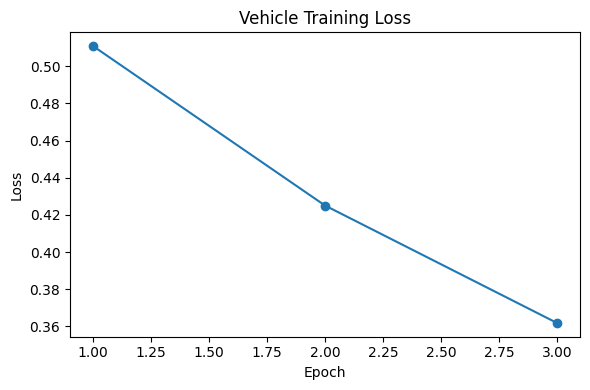

In [ ]:
epochs = range(1, len(losses) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, losses, marker="o")
plt.title("Vehicle Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(False)
plt.tight_layout()
plt.show()

## Evaluating Vehicle Detection Model Performance
Evaluates the vehicle detection model on the test data, reporting precision, recall, and F1-score.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

vehicle_model.eval()

true_values = []
predicted_values = []

with torch.inference_mode():

    for batch_images, batch_labels in vehicle_test_loader:

        batch_images = batch_images.to(device)

        logits = vehicle_model(batch_images)

        predictions = torch.sigmoid(logits).ge(0.5)

        predicted_values.extend(predictions.view(-1).cpu().tolist())
        true_values.extend(batch_labels.tolist())

precision = precision_score(true_values, predicted_values)
recall = recall_score(true_values, predicted_values)
f1 = f1_score(true_values, predicted_values)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

Precision: 0.8266845457593027
Recall: 0.9133333333333333
F1-score: 0.8678514868907268


## Visualizing Vehicle Detection Confusion Matrix
Generates and displays the confusion matrix for the vehicle detection model.

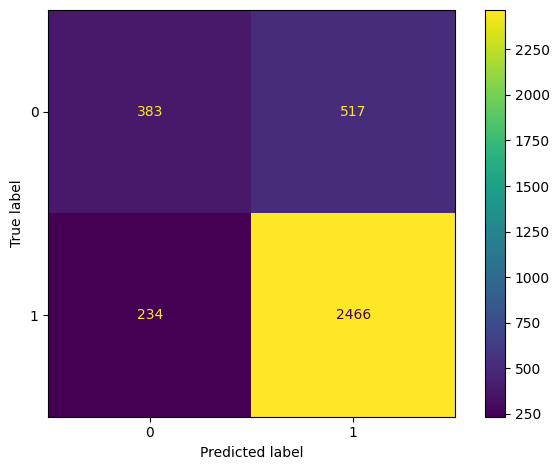

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

conf_matrix = confusion_matrix(true_values, predicted_values)

cm_display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)

cm_display.plot()

plt.tight_layout()
plt.show()

## Saving the Traffic Light Model
Saves the trained traffic light classification model's state dictionary to Google Drive.

In [ ]:
save_path = "/content/drive/MyDrive/carla_dataset/traffic_light_model.pth"

torch.save(
    obj=model.state_dict(),
    f=save_path
)

print("Traffic Light model saved")

Traffic Light model saved


## Saving the Pedestrian Detection Model
Saves the trained pedestrian detection model's state dictionary to Google Drive.

In [ ]:
save_location = "/content/drive/MyDrive/carla_dataset/pedestrian_model.pth"

torch.save(
    obj=pedestrian_model.state_dict(),
    f=save_location
)

print("Pedestrian model saved")

Pedestrian model saved


## Saving the Vehicle Detection Model
Saves the trained vehicle detection model's state dictionary to Google Drive.

In [ ]:
model_path = "/content/drive/MyDrive/carla_dataset/vehicle_model.pth"

torch.save(
    obj=vehicle_model.state_dict(),
    f=model_path
)

print("Vehicle model saved")

Vehicle model saved


## Verifying Saved Models
Re-lists all `.pth` files in the specified Google Drive directory to confirm that the models have been successfully saved.

In [ ]:
from pathlib import Path

model_directory = Path("/content/drive/MyDrive/carla_dataset")

for file_path in model_directory.rglob("*.pth"):
    print(file_path)

/content/drive/MyDrive/carla_dataset/traffic_light_model.pth
/content/drive/MyDrive/carla_dataset/pedestrian_model.pth
/content/drive/MyDrive/carla_dataset/vehicle_model.pth
